# 🚖 Ride-Hailing Data Analysis: NYC Taxi Trip Insights

## 📌 Project Overview

This project focuses on analyzing NYC taxi trip data to uncover meaningful insights that can support decision-making in a ride-hailing business environment. The analysis involves data cleaning, transformation, and exploratory analysis to understand patterns in taxi operations.

## 🧠 Objective

Assuming the role of a Data Analyst in a ride-hailing company, the primary goal of this project is to analyze trip data and extract actionable insights related to:

* 🚖 **Trip Behavior** – Understanding how customers use taxi services
* 💰 **Pricing Patterns** – Analyzing fare structures and consistency
* 📊 **Demand Trends** – Identifying peak hours and high-demand periods
* ⚙️ **Operational Inefficiencies** – Detecting delays, unusual trips, and inefficiencies

## 🎯 Key Goal

To transform raw taxi trip data into meaningful insights that can help improve pricing strategies, optimize operations, and enhance customer experience.

---


In [4]:
#(1)Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
#(2)
import pandas as pd

# Load parquet
df = pd.read_parquet("yellow_tripdata_2020-06.parquet")

print("Original shape:", df.shape)

# Take sample (important for GitHub)
df_small = df.sample(50000, random_state=42)

# Convert properly to CSV
df_small.to_csv("yellow_tripdata_2020-06.csv", index=False)

print("✅ CSV created correctly!")

Original shape: (549797, 19)
✅ CSV created correctly!


In [6]:
#(3)Initial Exploration
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (549797, 19)

Data Types:
 VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                      object
dtype: object

Missing Values:
 VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count           50718
trip_distance                 0
RatecodeID    

In [7]:
#Separate columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
datetime_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')
Categorical: Index(['store_and_fwd_flag', 'airport_fee'], dtype='object')


In [8]:
#(4)NumPy-Based Analysis
for col in ['trip_distance', 'fare_amount', 'total_amount']:
    data = df[col].dropna().values
    print(f"\n{col}")
    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    print("Std Dev:", np.std(data))


trip_distance
Mean: 4.104233799020365
Median: 1.86
Std Dev: 336.0126691385662

fare_amount
Mean: 13.60665365580387
Median: 9.0
Std Dev: 13.521143532107098

total_amount
Mean: 18.76877598459068
Median: 14.16
Std Dev: 15.178704730855946


In [9]:
#(5)Data Type Conversion
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [10]:
#(6)Missing Value Handling
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())
df['trip_distance'] = df['trip_distance'].fillna(df['trip_distance'].median())
df['tip_amount'] = df['tip_amount'].fillna(0)
df['payment_type'] = df['payment_type'].fillna(df['payment_type'].mode()[0])

In [11]:
#(7)Remove Invalid Records
df = df[
    (df['passenger_count'] > 0) &
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0)
].copy()

In [12]:
#(8)Remove Duplicates
df = df.drop_duplicates()

In [13]:
#(9)Categorical Cleaning
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].str.upper().str.strip()
df['payment_type'] = df['payment_type'].astype(str).str.strip()

In [14]:
#(10)Datetime Feature Engineering
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['month'] = df['tpep_pickup_datetime'].dt.month

In [15]:
#(11)Trip Duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Remove invalid durations
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 300)]

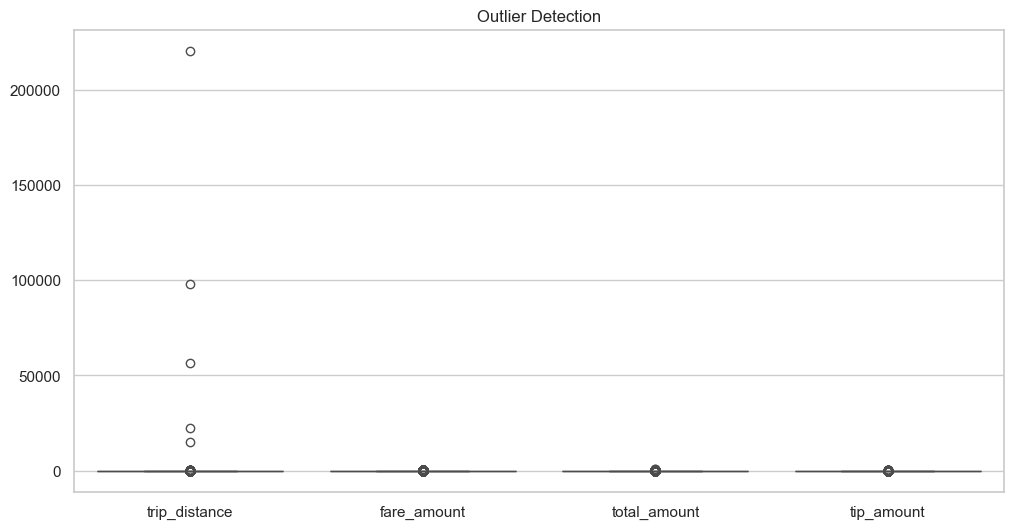

In [16]:
#(12)Outlier Detection (Boxplots)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['trip_distance','fare_amount','total_amount','tip_amount']])
plt.title("Outlier Detection")
plt.show()

In [17]:
#(13)Feature Engineering
df['fare_per_km'] = df['fare_amount'] / df['trip_distance']
df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100
df['trip_speed'] = df['trip_distance'] / (df['trip_duration'] / 60)

In [18]:
#(14)Final Validation
print(df.describe())
print(df.isnull().sum())

            VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  516047.000000                      516047                      516047   
mean        1.653964  2020-06-17 10:32:34.218255  2020-06-17 10:44:50.621763   
min         1.000000         2009-01-01 00:02:59         2009-01-01 00:07:40   
25%         1.000000  2020-06-10 09:58:28.500000  2020-06-10 10:08:21.500000   
50%         2.000000         2020-06-18 08:26:54         2020-06-18 08:37:58   
75%         2.000000  2020-06-24 19:48:03.500000  2020-06-24 19:58:35.500000   
max         5.000000         2020-07-01 00:02:40         2020-07-01 00:29:54   
std         0.476292                         NaN                         NaN   

       passenger_count  trip_distance     RatecodeID   PULocationID  \
count    516047.000000   516047.00000  466976.000000  516047.000000   
mean          1.364234        4.27860       1.025839     157.997564   
min           1.000000        0.01000       1.000000       1.00000

📊 SECTION 2: EDA

In [19]:
#1. Overall Stats
print("Total Trips:", len(df))
print("Average Fare:", df['fare_amount'].mean())
print("Average Distance:", df['trip_distance'].mean())

Total Trips: 516047
Average Fare: 13.537487593184345
Average Distance: 4.278600030617367


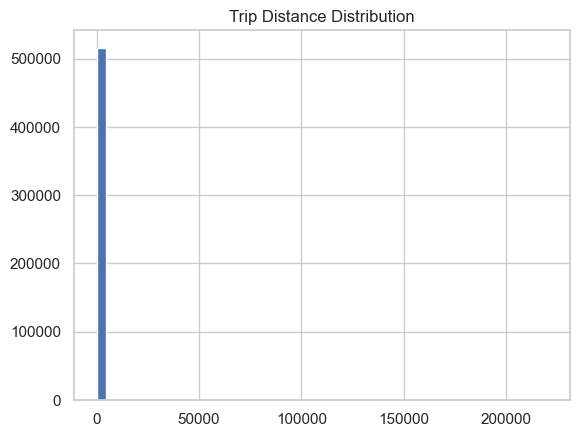

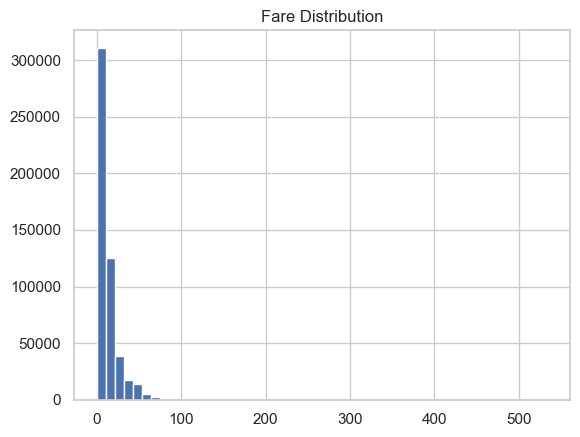

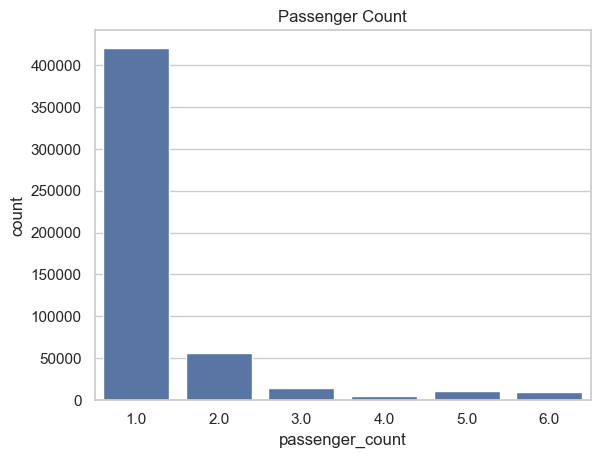

In [20]:
#2.univarate analysis
df['trip_distance'].hist(bins=50)
plt.title("Trip Distance Distribution")
plt.show()

df['fare_amount'].hist(bins=50)
plt.title("Fare Distribution")
plt.show()

sns.countplot(x='passenger_count', data=df)
plt.title("Passenger Count")
plt.show()

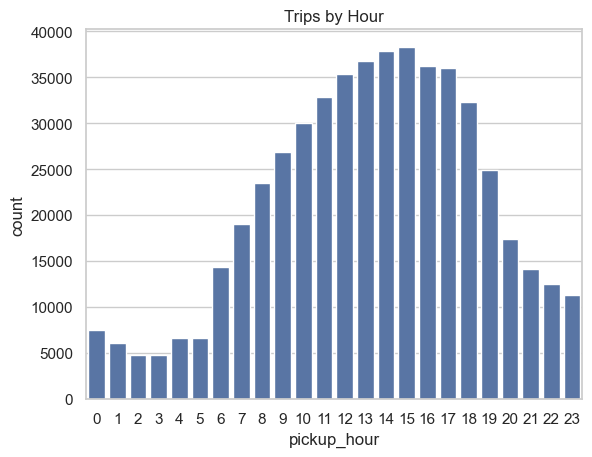

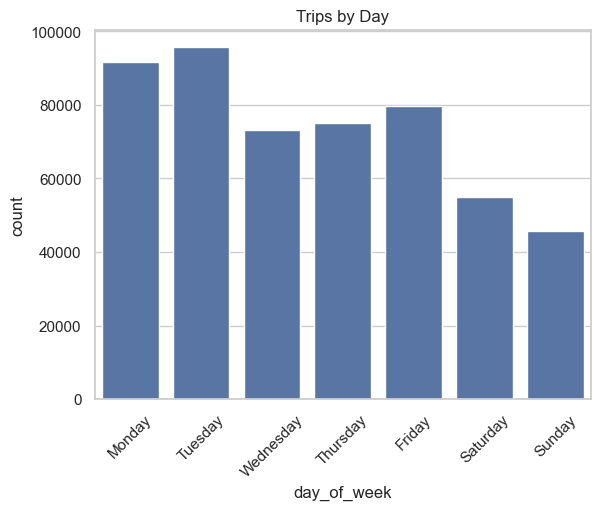

In [21]:
#3.Time-Based Analysis
sns.countplot(x='pickup_hour', data=df)
plt.title("Trips by Hour")
plt.show()

sns.countplot(x='day_of_week', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Trips by Day")
plt.xticks(rotation=45)
plt.show()

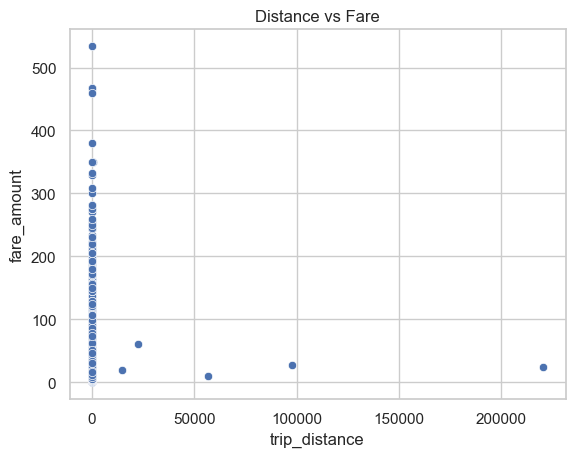

In [22]:
#4(Distance vs Fare)
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title("Distance vs Fare")
plt.show()

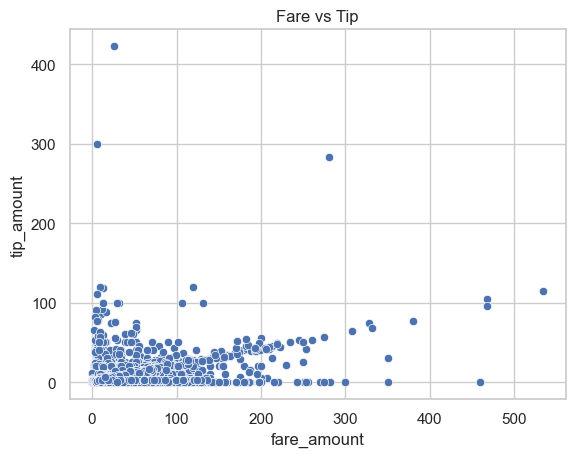

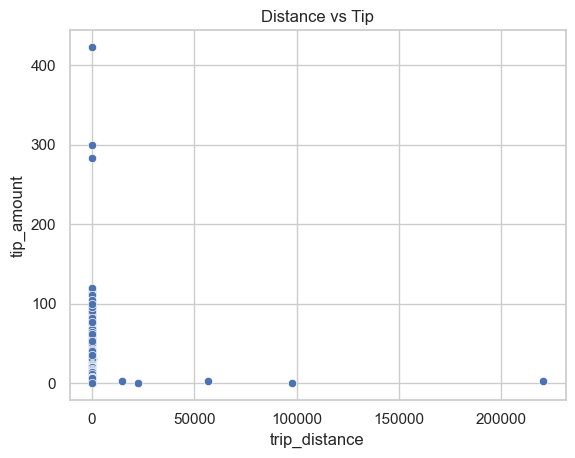

In [23]:
#(5)Tip Analysis
sns.scatterplot(x='fare_amount', y='tip_amount', data=df)
plt.title("Fare vs Tip")
plt.show()

sns.scatterplot(x='trip_distance', y='tip_amount', data=df)
plt.title("Distance vs Tip")
plt.show()

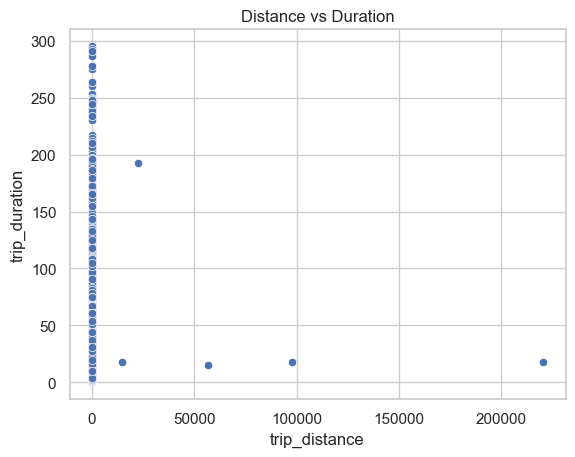

In [24]:
#(6)Duration Analysis
sns.scatterplot(x='trip_distance', y='trip_duration', data=df)
plt.title("Distance vs Duration")
plt.show()

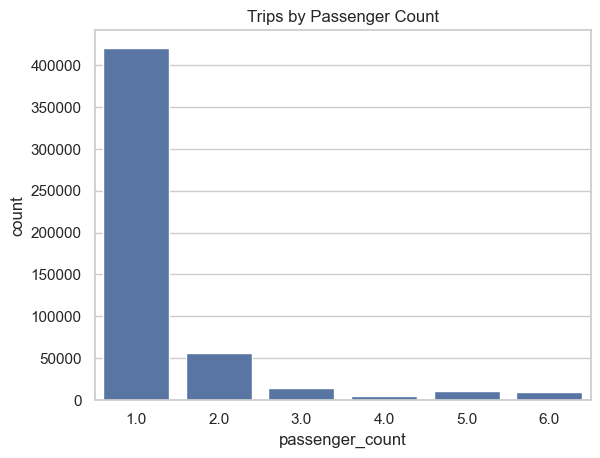

In [25]:
#(7)Passenger Analysis
sns.countplot(x='passenger_count', data=df)
plt.title("Trips by Passenger Count")
plt.show()

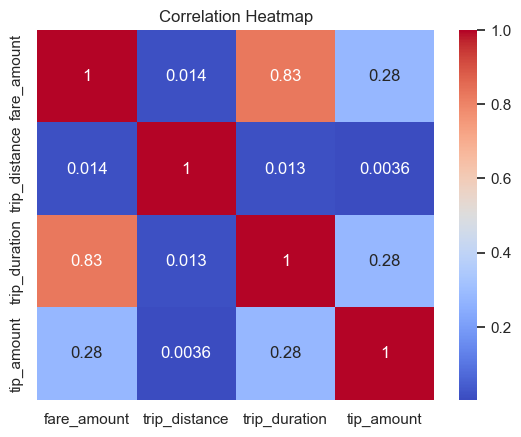

In [26]:
#(9)Correlation Heatmap
corr = df[['fare_amount','trip_distance','trip_duration','tip_amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

SECTION 3: INSIGHTS

In [27]:
#(1)Basic
print("Avg Distance:", df['trip_distance'].mean())
print("Avg Fare:", df['fare_amount'].mean())

Avg Distance: 4.278600030617367
Avg Fare: 13.537487593184345


In [28]:
#(2)Trip Behavior
print("Most common passenger:", df['passenger_count'].mode()[0])

Most common passenger: 1.0


In [29]:
#(3)Time Insights
print("Peak Hour:", df['pickup_hour'].mode()[0])
print("Highest Demand Day:", df['day_of_week'].mode()[0])

Peak Hour: 15
Highest Demand Day: Tuesday


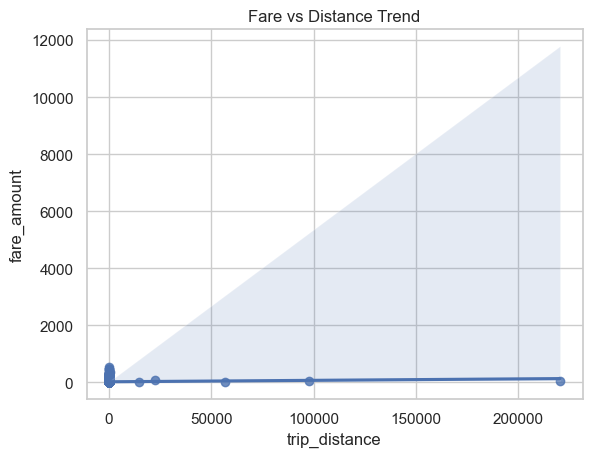

In [30]:
#(4)Pricing
sns.regplot(x='trip_distance', y='fare_amount', data=df)
plt.title("Fare vs Distance Trend")
plt.show()

In [31]:
#tips
print("Trips with no tip:", len(df[df['tip_amount']==0]))

Trips with no tip: 203611


In [32]:
#operational
weekday = df[df['day_of_week'].isin(['Monday','Tuesday','Wednesday','Thursday','Friday'])]
weekend = df[df['day_of_week'].isin(['Saturday','Sunday'])]

print("Weekday Trips:", len(weekday))
print("Weekend Trips:", len(weekend))

Weekday Trips: 415354
Weekend Trips: 100693


In [33]:
#Outliers
print("High Fare Trips:")
print(df[df['fare_amount'] > df['fare_amount'].quantile(0.99)])

High Fare Trips:
        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
382            2  2020-06-01 04:20:13   2020-06-01 04:55:23              1.0   
463            2  2020-06-01 04:59:30   2020-06-01 05:27:17              1.0   
535            2  2020-06-01 05:18:08   2020-06-01 05:50:28              1.0   
913            2  2020-06-01 06:24:15   2020-06-01 07:04:40              1.0   
994            2  2020-06-01 06:57:02   2020-06-01 07:33:02              1.0   
...          ...                  ...                   ...              ...   
549706         2  2020-06-30 21:17:00   2020-06-30 21:53:00              1.0   
549750         2  2020-06-30 22:04:12   2020-06-30 22:55:36              1.0   
549752         2  2020-06-30 22:52:00   2020-06-30 23:36:00              1.0   
549781         2  2020-06-30 23:32:00   2020-07-01 00:09:00              1.0   
549788         2  2020-06-30 23:16:23   2020-07-01 00:10:03              1.0   

        trip_distance 

In [34]:
#Advanced Insights
inefficient = df[(df['trip_duration'] > 60) & (df['trip_distance'] < 2)]
print("Inefficient Trips:", len(inefficient))

Inefficient Trips: 30
